In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel('ecommerce_sales_data.xlsx')
df

,OrderID,Date,CustomerID,Product_Category,Product_Name,Quantity,UnitPrice,Discount,Region
0,ORD0001,2025-11-24,CUST027,Clothing,Jeans,6,93.20,0.12,Central
1,ORD0002,2025-02-27,CUST025,Electronics,Smartphone,10,134.67,NaN,South
2,ORD0003,2025-01-13,CUST025,Books,Machine Learning Intro,9,178.20,0.04,North
3,ORD0004,2025-05-21,CUST002,Home & Kitchen,Coffee Maker,3,199.86,0.01,North
4,ORD0005,2025-05-06,CUST008,Electronics,Laptop,7,144.85,0.17,North
...,...,...,...,...,...,...,...,...,...
95,ORD0096,2025-12-19,CUST021,Books,Python for Data Analysis,4,73.96,0.14,North
96,ORD0097,2025-10-13,CUST010,Home & Kitchen,Microwave,7,73.63,0.12,North
97,ORD0098,2025-04-23,NaN,Books,Python for Data Analysis,7,136.39,NaN,North
98,ORD0099,2025-12-17,CUST021,Home & Kitchen,Microwave,3,18.42,0.02,Central


Phần 1: Khởi tạo và Đọc dữ liệu

In [20]:
df.head(7)
# 7 dòng đầu


,OrderID,Date,CustomerID,Product_Category,Product_Name,Quantity,UnitPrice,Discount,Region
0,ORD0001,2025-11-24,CUST027,Clothing,Jeans,6,93.20,0.12,Central
1,ORD0002,2025-02-27,CUST025,Electronics,Smartphone,10,134.67,NaN,South
2,ORD0003,2025-01-13,CUST025,Books,Machine Learning Intro,9,178.20,0.04,North
3,ORD0004,2025-05-21,CUST002,Home & Kitchen,Coffee Maker,3,199.86,0.01,North
4,ORD0005,2025-05-06,CUST008,Electronics,Laptop,7,144.85,0.17,North
5,ORD0006,2025-04-25,CUST027,Electronics,Laptop,3,138.23,NaN,Central
6,ORD0007,2025-03-13,CUST002,Books,Data Science Handbook,1,71.97,0.04,South


In [16]:
df.tail(5)
# 5 dòng cuối


,OrderID,Date,CustomerID,Product_Category,Product_Name,Quantity,UnitPrice,Discount,Region
95,ORD0096,2025-12-19,CUST021,Books,Python for Data Analysis,4,73.96,0.14,North
96,ORD0097,2025-10-13,CUST010,Home & Kitchen,Microwave,7,73.63,0.12,North
97,ORD0098,2025-04-23,NaN,Books,Python for Data Analysis,7,136.39,NaN,North
98,ORD0099,2025-12-17,CUST021,Home & Kitchen,Microwave,3,18.42,0.02,Central
99,ORD0100,2025-06-16,CUST017,Home & Kitchen,Coffee Maker,10,107.48,NaN,Central


In [17]:
df.shape
# Số dòng, cột

(100, 9)

In [18]:
df.info()
# Thông tin chi tiết

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   OrderID           100 non-null    object 
 1   Date              100 non-null    object 
 2   CustomerID        95 non-null     object 
 3   Product_Category  100 non-null    object 
 4   Product_Name      100 non-null    object 
 5   Quantity          100 non-null    int64  
 6   UnitPrice         100 non-null    float64
 7   Discount          65 non-null     float64
 8   Region            100 non-null    object 
dtypes: float64(2), int64(1), object(6)
memory usage: 7.2+ KB


In [19]:
df.describe()
# Thống kê mô tả

,Quantity,UnitPrice,Discount
count,100.000000,100.000000,65.000000
mean,5.150000,153.546200,0.141385
std,2.896794,77.360231,0.079134
min,-5.000000,11.610000,0.010000
25%,3.000000,84.445000,0.080000
50%,5.000000,154.880000,0.150000
75%,7.000000,215.792500,0.210000
max,10.000000,296.490000,0.300000


Phần 2: Khám phá và Làm sạch dữ liệu

In [34]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product_Category,0
Product_Name,0
Quantity,0
UnitPrice,0
Discount,0
Region,0


In [40]:
df['Discount'].fillna(0, inplace=True)

/tmp/ipykernel_7911/1275870825.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Discount'].fillna(0, inplace=True)


In [41]:
df['CustomerID'].fillna('GUEST', inplace=True)

/tmp/ipykernel_7911/718389851.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CustomerID'].fillna('GUEST', inplace=True)


In [44]:
df['Date'] = pd.to_datetime(df['Date'])

In [45]:
df = df.drop_duplicates()

Phần 3: Trích xuất và Biến đổi dữ liệu (Feature Engineering)

In [49]:
df['Revenue'] = df['Quantity'] * df['UnitPrice'] * (1 - df['Discount'])
df

,OrderID,Date,CustomerID,Product_Category,Product_Name,Quantity,UnitPrice,Discount,Region,Revenue
0,ORD0001,2025-11-24,CUST027,Clothing,Jeans,6,93.20,0.12,Central,492.0960
1,ORD0002,2025-02-27,CUST025,Electronics,Smartphone,10,134.67,0.00,South,1346.7000
2,ORD0003,2025-01-13,CUST025,Books,Machine Learning Intro,9,178.20,0.04,North,1539.6480
3,ORD0004,2025-05-21,CUST002,Home & Kitchen,Coffee Maker,3,199.86,0.01,North,593.5842
4,ORD0005,2025-05-06,CUST008,Electronics,Laptop,7,144.85,0.17,North,841.5785
...,...,...,...,...,...,...,...,...,...,...
95,ORD0096,2025-12-19,CUST021,Books,Python for Data Analysis,4,73.96,0.14,North,254.4224
96,ORD0097,2025-10-13,CUST010,Home & Kitchen,Microwave,7,73.63,0.12,North,453.5608
97,ORD0098,2025-04-23,GUEST,Books,Python for Data Analysis,7,136.39,0.00,North,954.7300
98,ORD0099,2025-12-17,CUST021,Home & Kitchen,Microwave,3,18.42,0.02,Central,54.1548


In [52]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.day_name()
df

,OrderID,Date,CustomerID,Product_Category,Product_Name,Quantity,UnitPrice,Discount,Region,Revenue,Year,Month,DayOfWeek
0,ORD0001,2025-11-24,CUST027,Clothing,Jeans,6,93.20,0.12,Central,492.0960,2025,11,Monday
1,ORD0002,2025-02-27,CUST025,Electronics,Smartphone,10,134.67,0.00,South,1346.7000,2025,2,Thursday
2,ORD0003,2025-01-13,CUST025,Books,Machine Learning Intro,9,178.20,0.04,North,1539.6480,2025,1,Monday
3,ORD0004,2025-05-21,CUST002,Home & Kitchen,Coffee Maker,3,199.86,0.01,North,593.5842,2025,5,Wednesday
4,ORD0005,2025-05-06,CUST008,Electronics,Laptop,7,144.85,0.17,North,841.5785,2025,5,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,ORD0096,2025-12-19,CUST021,Books,Python for Data Analysis,4,73.96,0.14,North,254.4224,2025,12,Friday
96,ORD0097,2025-10-13,CUST010,Home & Kitchen,Microwave,7,73.63,0.12,North,453.5608,2025,10,Monday
97,ORD0098,2025-04-23,GUEST,Books,Python for Data Analysis,7,136.39,0.00,North,954.7300,2025,4,Wednesday
98,ORD0099,2025-12-17,CUST021,Home & Kitchen,Microwave,3,18.42,0.02,Central,54.1548,2025,12,Wednesday


In [54]:
def categorize_price(price):
    if price >= 150:
        return 'High'
    elif price >= 50:
        return 'Medium'
    else:
        return 'Low'

df['Price_Segment'] = df['UnitPrice'].apply(categorize_price)
df

,OrderID,Date,CustomerID,Product_Category,Product_Name,Quantity,UnitPrice,Discount,Region,Revenue,Year,Month,DayOfWeek,Price_Segment
0,ORD0001,2025-11-24,CUST027,Clothing,Jeans,6,93.20,0.12,Central,492.0960,2025,11,Monday,Medium
1,ORD0002,2025-02-27,CUST025,Electronics,Smartphone,10,134.67,0.00,South,1346.7000,2025,2,Thursday,Medium
2,ORD0003,2025-01-13,CUST025,Books,Machine Learning Intro,9,178.20,0.04,North,1539.6480,2025,1,Monday,High
3,ORD0004,2025-05-21,CUST002,Home & Kitchen,Coffee Maker,3,199.86,0.01,North,593.5842,2025,5,Wednesday,High
4,ORD0005,2025-05-06,CUST008,Electronics,Laptop,7,144.85,0.17,North,841.5785,2025,5,Tuesday,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,ORD0096,2025-12-19,CUST021,Books,Python for Data Analysis,4,73.96,0.14,North,254.4224,2025,12,Friday,Medium
96,ORD0097,2025-10-13,CUST010,Home & Kitchen,Microwave,7,73.63,0.12,North,453.5608,2025,10,Monday,Medium
97,ORD0098,2025-04-23,GUEST,Books,Python for Data Analysis,7,136.39,0.00,North,954.7300,2025,4,Wednesday,Medium
98,ORD0099,2025-12-17,CUST021,Home & Kitchen,Microwave,3,18.42,0.02,Central,54.1548,2025,12,Wednesday,Low


Phần 4: Lọc và Truy vấn dữ liệu

In [56]:
result = df[(df['Region'] == 'North') & (df['Revenue'] > 300)]
df
# Lọc cơ bản

,OrderID,Date,CustomerID,Product_Category,Product_Name,Quantity,UnitPrice,Discount,Region,Revenue,Year,Month,DayOfWeek,Price_Segment
0,ORD0001,2025-11-24,CUST027,Clothing,Jeans,6,93.20,0.12,Central,492.0960,2025,11,Monday,Medium
1,ORD0002,2025-02-27,CUST025,Electronics,Smartphone,10,134.67,0.00,South,1346.7000,2025,2,Thursday,Medium
2,ORD0003,2025-01-13,CUST025,Books,Machine Learning Intro,9,178.20,0.04,North,1539.6480,2025,1,Monday,High
3,ORD0004,2025-05-21,CUST002,Home & Kitchen,Coffee Maker,3,199.86,0.01,North,593.5842,2025,5,Wednesday,High
4,ORD0005,2025-05-06,CUST008,Electronics,Laptop,7,144.85,0.17,North,841.5785,2025,5,Tuesday,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,ORD0096,2025-12-19,CUST021,Books,Python for Data Analysis,4,73.96,0.14,North,254.4224,2025,12,Friday,Medium
96,ORD0097,2025-10-13,CUST010,Home & Kitchen,Microwave,7,73.63,0.12,North,453.5608,2025,10,Monday,Medium
97,ORD0098,2025-04-23,GUEST,Books,Python for Data Analysis,7,136.39,0.00,North,954.7300,2025,4,Wednesday,Medium
98,ORD0099,2025-12-17,CUST021,Home & Kitchen,Microwave,3,18.42,0.02,Central,54.1548,2025,12,Wednesday,Low


In [57]:
count = len(df[(df['Product_Category'] == 'Electronics') & (df['Discount'] == 0)])
# Đếm

In [58]:
result = df[(df['Month'] >= 3) & (df['Month'] <= 6)]
# Lọc khoảng tháng

In [62]:
result = df.nlargest(10, 'Revenue')
df

,OrderID,Date,CustomerID,Product_Category,Product_Name,Quantity,UnitPrice,Discount,Region,Revenue,Year,Month,DayOfWeek,Price_Segment
0,ORD0001,2025-11-24,CUST027,Clothing,Jeans,6,93.20,0.12,Central,492.0960,2025,11,Monday,Medium
1,ORD0002,2025-02-27,CUST025,Electronics,Smartphone,10,134.67,0.00,South,1346.7000,2025,2,Thursday,Medium
2,ORD0003,2025-01-13,CUST025,Books,Machine Learning Intro,9,178.20,0.04,North,1539.6480,2025,1,Monday,High
3,ORD0004,2025-05-21,CUST002,Home & Kitchen,Coffee Maker,3,199.86,0.01,North,593.5842,2025,5,Wednesday,High
4,ORD0005,2025-05-06,CUST008,Electronics,Laptop,7,144.85,0.17,North,841.5785,2025,5,Tuesday,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,ORD0096,2025-12-19,CUST021,Books,Python for Data Analysis,4,73.96,0.14,North,254.4224,2025,12,Friday,Medium
96,ORD0097,2025-10-13,CUST010,Home & Kitchen,Microwave,7,73.63,0.12,North,453.5608,2025,10,Monday,Medium
97,ORD0098,2025-04-23,GUEST,Books,Python for Data Analysis,7,136.39,0.00,North,954.7300,2025,4,Wednesday,Medium
98,ORD0099,2025-12-17,CUST021,Home & Kitchen,Microwave,3,18.42,0.02,Central,54.1548,2025,12,Wednesday,Low


In [61]:
max_order = df.loc[df['Quantity'].idxmax()]
df

,OrderID,Date,CustomerID,Product_Category,Product_Name,Quantity,UnitPrice,Discount,Region,Revenue,Year,Month,DayOfWeek,Price_Segment
0,ORD0001,2025-11-24,CUST027,Clothing,Jeans,6,93.20,0.12,Central,492.0960,2025,11,Monday,Medium
1,ORD0002,2025-02-27,CUST025,Electronics,Smartphone,10,134.67,0.00,South,1346.7000,2025,2,Thursday,Medium
2,ORD0003,2025-01-13,CUST025,Books,Machine Learning Intro,9,178.20,0.04,North,1539.6480,2025,1,Monday,High
3,ORD0004,2025-05-21,CUST002,Home & Kitchen,Coffee Maker,3,199.86,0.01,North,593.5842,2025,5,Wednesday,High
4,ORD0005,2025-05-06,CUST008,Electronics,Laptop,7,144.85,0.17,North,841.5785,2025,5,Tuesday,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,ORD0096,2025-12-19,CUST021,Books,Python for Data Analysis,4,73.96,0.14,North,254.4224,2025,12,Friday,Medium
96,ORD0097,2025-10-13,CUST010,Home & Kitchen,Microwave,7,73.63,0.12,North,453.5608,2025,10,Monday,Medium
97,ORD0098,2025-04-23,GUEST,Books,Python for Data Analysis,7,136.39,0.00,North,954.7300,2025,4,Wednesday,Medium
98,ORD0099,2025-12-17,CUST021,Home & Kitchen,Microwave,3,18.42,0.02,Central,54.1548,2025,12,Wednesday,Low


Phần 5: Phân tích, Gom nhóm và Tổng hợp

In [67]:
result = df.groupby('Region')['Revenue'].sum()
display(result)

,Revenue
Region,
Central,30679.9509
North,23579.3016
South,18995.3702


In [69]:
result = df.groupby('Product_Category').agg({
    'Quantity': 'mean',
    'UnitPrice': 'mean'
})
display(result)

,Quantity,UnitPrice
Product_Category,,
Books,5.071429,124.435000
Clothing,5.321429,167.446786
Electronics,5.551724,166.513103
Home & Kitchen,4.620690,141.211724


In [70]:
result = df.groupby('Month').size()
display(result)

,0
Month,
1,7
2,12
3,7
4,11
5,11
6,4
7,9
8,7
9,1


In [71]:
result = df[df['CustomerID'] != 'GUEST'].groupby('CustomerID')['Revenue'].sum().head(3)
display(result)

,Revenue
CustomerID,
CUST001,3513.1000
CUST002,662.6754
CUST003,2250.2712


Phần 6: Trực quan hóa dữ liệu cơ bản

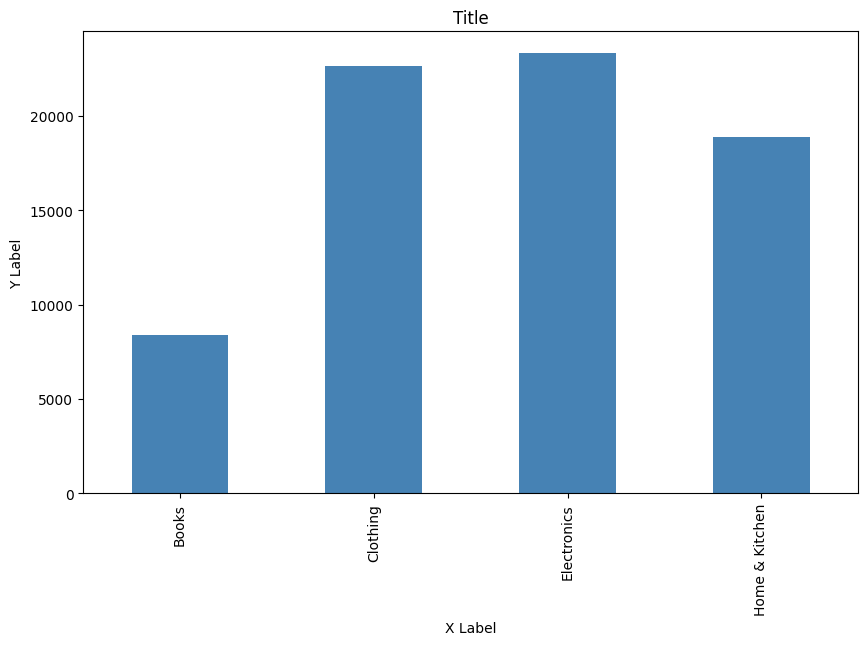

In [72]:
fig, ax = plt.subplots(figsize=(10, 6))
revenue = df.groupby('Product_Category')['Revenue'].sum()
revenue.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Title')
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
plt.show()

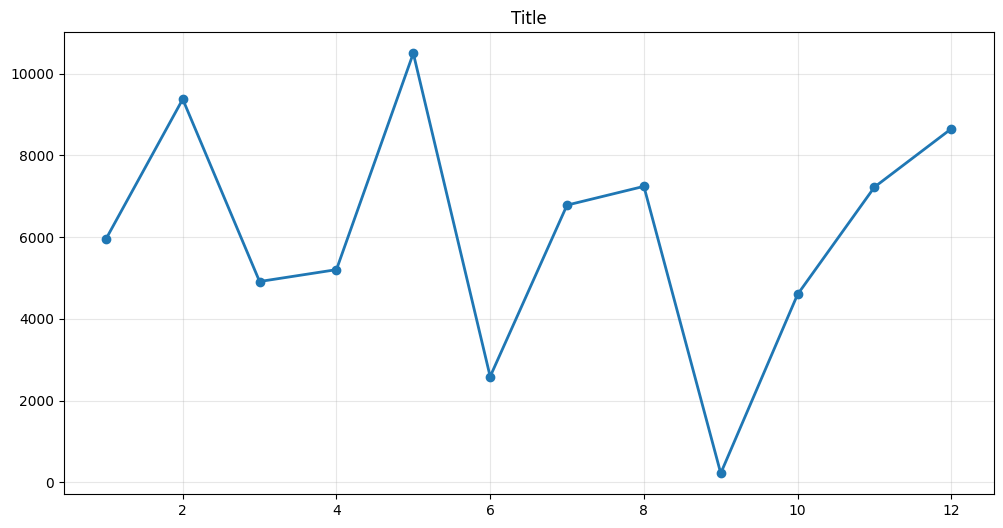

In [73]:
fig, ax = plt.subplots(figsize=(12, 6))
monthly = df.groupby('Month')['Revenue'].sum()
ax.plot(monthly.index, monthly.values, marker='o', linewidth=2)
ax.set_title('Title')
ax.grid(True, alpha=0.3)
plt.show()

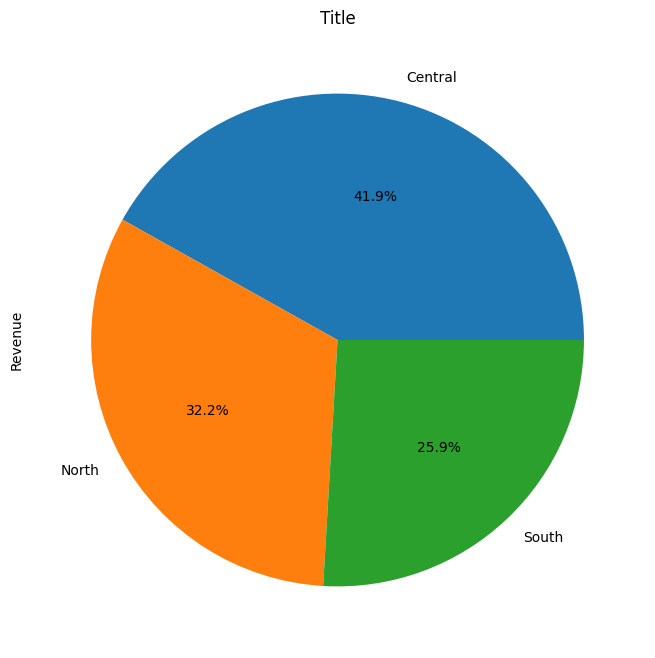

In [74]:
fig, ax = plt.subplots(figsize=(10, 8))
region = df.groupby('Region')['Revenue'].sum()
region.plot(kind='pie', ax=ax, autopct='%1.1f%%')
ax.set_title('Title')
plt.show()

In [75]:
df.to_excel('result.xlsx', index=False)

df.to_csv('result.csv', index=False)

from google.colab import files
files.download('result.xlsx')

plt.savefig('chart.png', dpi=300, bbox_inches='tight')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>